# Sales Prediction Using Python
**Track:** Data Science | **Task 5**

**Objective:** Build regression models that predict product sales from advertising spend across three media channels: **TV, Radio and Newspaper**.

**Dataset:** the classic *Advertising* dataset (from *An Introduction to Statistical Learning*), stored in `data/Advertising.csv`. It has 200 markets. Advertising budgets are in **thousands of dollars** and Sales is in **thousands of units**.

**Stack:** Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook

**Outline**
1. Import libraries and load data
2. Exploratory Data Analysis (null check, descriptive statistics)
3. Visualisations: pairplot, scatter plots, correlation heatmap
4. Train/test split
5. Baseline: Linear Regression
6. Additional models: Polynomial Regression and Random Forest
7. Evaluation (MAE, RMSE, R2)
8. Residual plot analysis
9. Interpretation: which channel has the highest impact?
10. Predict sales for a new budget

## 1. Import Libraries and Load Data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
# The first column of the CSV is just a row number, so we use it as the index
df = pd.read_csv("data/Advertising.csv", index_col=0)

print("Shape:", df.shape)
df.head()

Shape: (200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## 2. Exploratory Data Analysis (EDA)

### 2.1 Structure and data types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


### 2.2 Null values and duplicates

In [4]:
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Total missing values: 0
Duplicate rows: 0


### 2.3 Descriptive statistics

In [5]:
df.describe().round(2)

,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


**Observations**
- 200 rows and 4 numeric columns, with **no missing values and no duplicates**, so no cleaning is needed.
- TV budgets are the largest (average about 147 thousand dollars), Radio is smaller (about 23) and Newspaper is in between (about 30).
- Sales range from about 1.6 to 27 thousand units, with an average of about 14.

## 3. Visualisations

### 3.1 Pairplot of all features

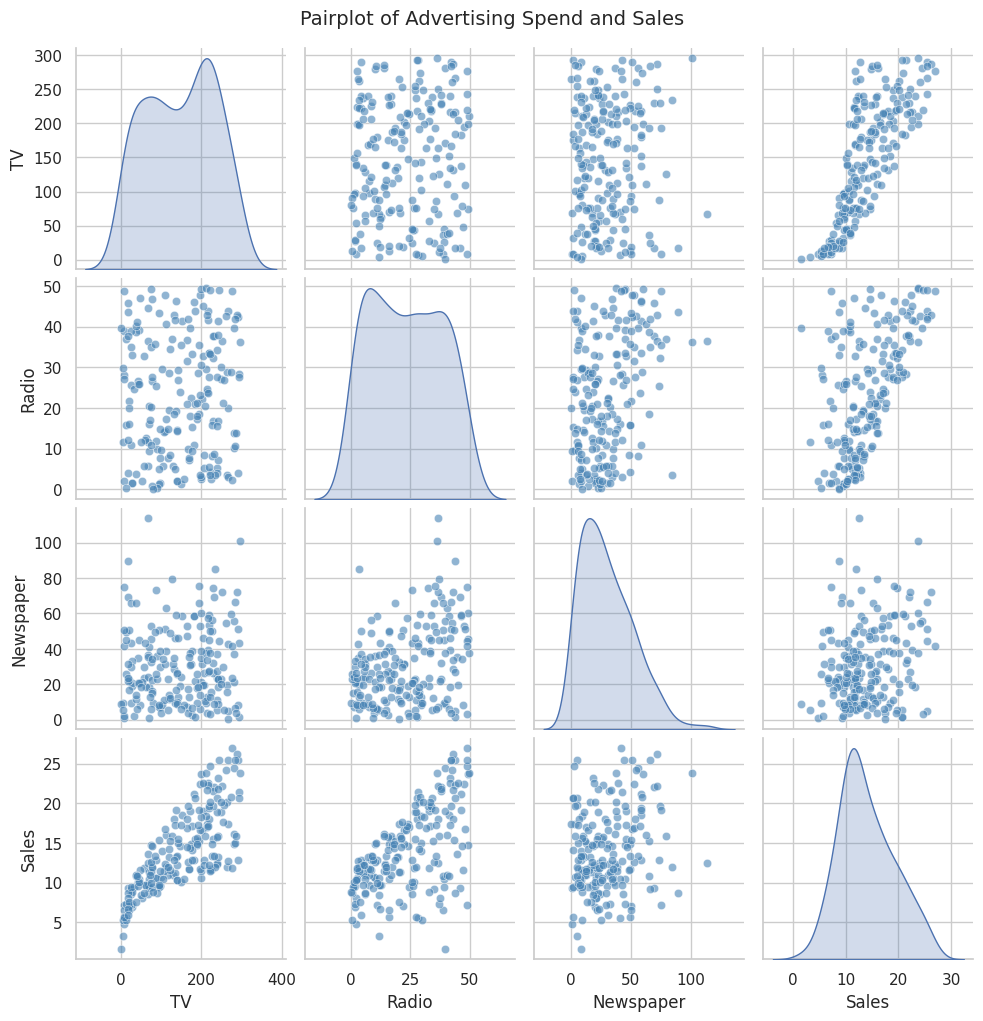

In [6]:
sns.pairplot(df, diag_kind="kde", plot_kws={"alpha": 0.6, "color": "steelblue"})
plt.suptitle("Pairplot of Advertising Spend and Sales", y=1.02, fontsize=14)
plt.show()

**Observation:** The `Sales` row shows the story. Sales rises steadily with **TV** spend, rises with **Radio** spend but with more scatter, and shows almost no clear pattern with **Newspaper** spend. The three advertising channels do not show strong patterns between each other.

### 3.2 Individual scatter plots: Sales vs each channel

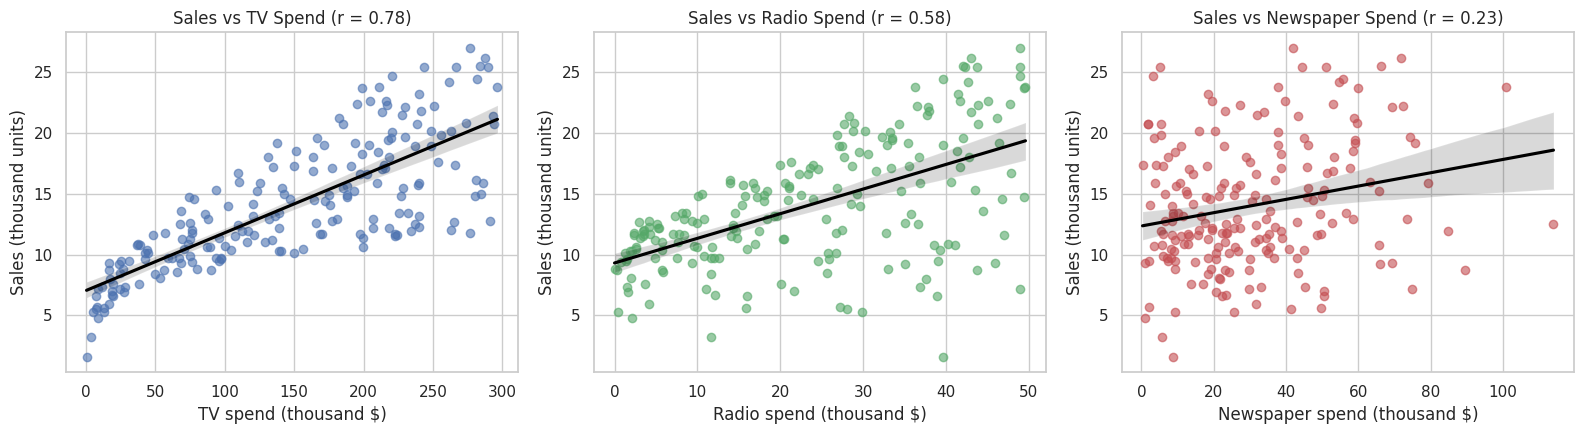

In [7]:
channels = ["TV", "Radio", "Newspaper"]
colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, ch, col in zip(axes, channels, colors):
    sns.regplot(data=df, x=ch, y="Sales", ax=ax, color=col,
                scatter_kws={"alpha": 0.6}, line_kws={"color": "black"})
    r = df[ch].corr(df["Sales"])
    ax.set_title(f"Sales vs {ch} Spend (r = {r:.2f})")
    ax.set_xlabel(f"{ch} spend (thousand $)")
    ax.set_ylabel("Sales (thousand units)")
plt.tight_layout()
plt.show()

**Observations**
- **TV:** a strong, clear upward relationship (r about 0.78). The points curve slightly, so the effect flattens at high budgets.
- **Radio:** a moderate upward relationship (r about 0.58) with a wider spread.
- **Newspaper:** a weak relationship (r about 0.23) and a very wide spread. On its own, newspaper spend predicts sales poorly.

### 3.3 Correlation matrix heatmap

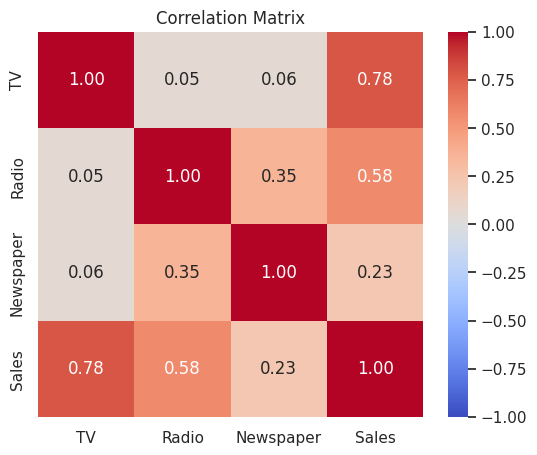

In [8]:
plt.figure(figsize=(6.5, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix")
plt.show()

**Observations**
- **Sales correlates most with TV (0.78)**, then Radio (0.58), then Newspaper (0.23).
- The channels are only weakly correlated with each other, apart from **Radio and Newspaper (0.35)**. This means there is little multicollinearity, so each channel's effect can be separated fairly cleanly.
- Newspaper's modest 0.23 correlation with Sales may partly come from its link with Radio: markets that spend on radio also tend to spend somewhat more on newspapers. The model below will show whether Newspaper has its own effect.

## 4. Train/Test Split (80/20)

In [9]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)

Training set: (160, 3)
Test set    : (40, 3)


## 5. Baseline Model: Linear Regression
Linear Regression assumes `Sales = b0 + b1*TV + b2*Radio + b3*Newspaper`. It is simple and easy to interpret, so it is a good baseline.

In [10]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print(f"Intercept: {lin_reg.intercept_:.3f}")
for name, coef in zip(X.columns, lin_reg.coef_):
    print(f"Coefficient for {name:<10}: {coef:.4f}")

Intercept: 2.979
Coefficient for TV        : 0.0447
Coefficient for Radio     : 0.1892
Coefficient for Newspaper : 0.0028


## 6. Additional Models
- **Polynomial Regression (degree 2):** adds squared terms and **interaction terms** (such as TV x Radio), so it can capture the curve in the TV relationship and any combined effect of two channels.
- **Random Forest Regressor:** an average of many decision trees that can capture non-linear patterns without a formula.

In [11]:
poly_reg = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LinearRegression(),
)
poly_reg.fit(X_train, y_train)

rf_reg = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)
rf_reg.fit(X_train, y_train)

models = {
    "Linear Regression": lin_reg,
    "Polynomial Regression (deg 2)": poly_reg,
    "Random Forest": rf_reg,
}
print("All models trained.")

All models trained.


## 7. Evaluation
- **MAE:** the average size of the error, in thousand units of sales.
- **RMSE:** like MAE but punishes large errors more.
- **R2:** the share of the variation in sales the model explains (1.0 is perfect).
- **CV R2:** the average R2 from 5-fold cross-validation, a more stable check than a single 40-row test set.

In [12]:
results = []
for name, model in models.items():
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2 (test)": r2_score(y_test, pred),
        "R2 (train)": r2_score(y_train, model.predict(X_train)),
        "CV R2 (5-fold)": cross_val_score(model, X, y, cv=5, scoring="r2").mean(),
    })

results_df = pd.DataFrame(results).set_index("Model").sort_values("R2 (test)", ascending=False)
display(results_df.round(3))

,MAE,RMSE,R2 (test),R2 (train),CV R2 (5-fold)
Model,,,,,
Polynomial Regression (deg 2),0.526,0.643,0.987,0.986,0.984
Random Forest,0.613,0.740,0.983,0.997,0.976
Linear Regression,1.461,1.782,0.899,0.896,0.887


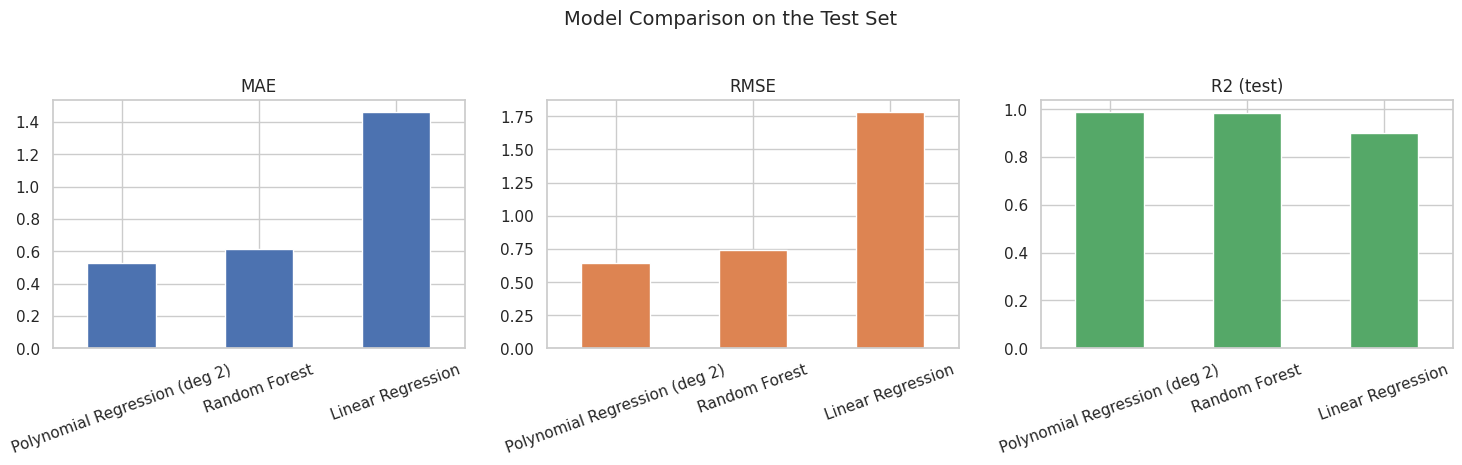

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric, color in zip(axes, ["MAE", "RMSE", "R2 (test)"], ["#4C72B0", "#DD8452", "#55A868"]):
    results_df[metric].plot(kind="bar", ax=ax, color=color, rot=20)
    ax.set_title(metric)
    ax.set_xlabel("")
plt.suptitle("Model Comparison on the Test Set", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()

Best model: Polynomial Regression (deg 2)


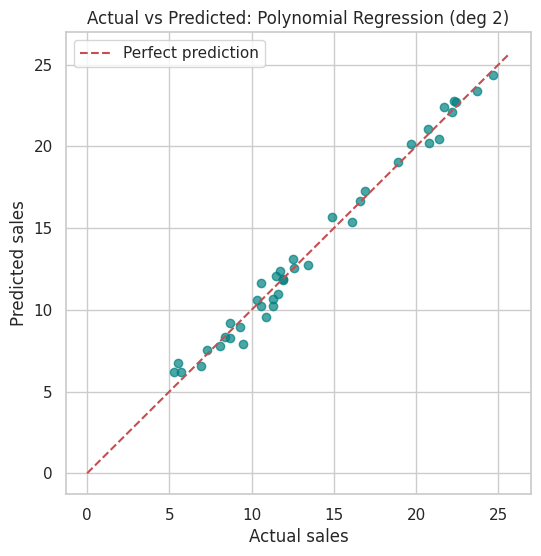

In [14]:
best_name = results_df.index[0]      # highest test R2
best_model = models[best_name]
print("Best model:", best_name)

best_pred = best_model.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.7, color="teal")
lims = [0, max(y_test.max(), best_pred.max()) + 1]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual sales")
plt.ylabel("Predicted sales")
plt.title(f"Actual vs Predicted: {best_name}")
plt.legend()
plt.show()

**Observations**
- **Linear Regression** is a decent baseline but clearly the weakest: it misses the curved relationship and the combined effect of TV and Radio.
- **Polynomial Regression** and **Random Forest** are far more accurate, with R2 above 0.98 and an error less than half that of the baseline.
- The Random Forest fits its training data almost perfectly (train R2 near 1.0) but scores a little lower on test data, which is a mild sign of overfitting. Polynomial Regression has train and test scores that are almost equal, so it generalises better.

## 8. Residual Analysis
A **residual** is `actual - predicted`. If a model has captured the pattern, residuals should look **random**: scattered evenly around zero with no shape. A curve or funnel in the residuals means the model is **systematically** missing something.

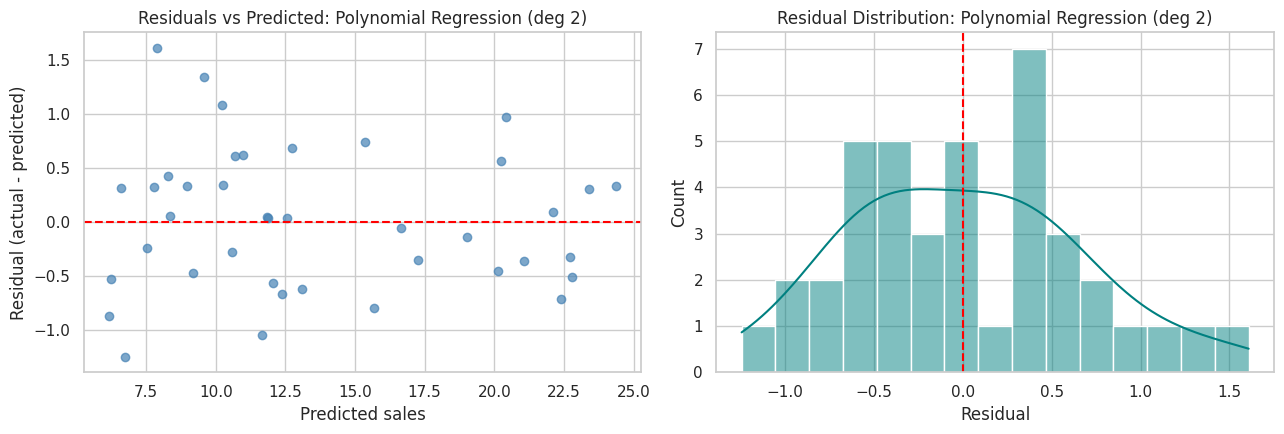

Polynomial Regression (deg 2): mean residual = 0.017, std = 0.651


In [15]:
def residual_plots(model, name):
    pred = model.predict(X_test)
    resid = y_test - pred

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].scatter(pred, resid, alpha=0.7, color="steelblue")
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_xlabel("Predicted sales")
    axes[0].set_ylabel("Residual (actual - predicted)")
    axes[0].set_title(f"Residuals vs Predicted: {name}")

    sns.histplot(resid, bins=15, kde=True, color="teal", ax=axes[1])
    axes[1].axvline(0, color="red", linestyle="--")
    axes[1].set_xlabel("Residual")
    axes[1].set_title(f"Residual Distribution: {name}")

    plt.tight_layout()
    plt.show()
    print(f"{name}: mean residual = {resid.mean():.3f}, std = {resid.std():.3f}")

# Residuals of the best model
residual_plots(best_model, best_name)

### Comparison with the baseline
The best model's residuals are shown above. For contrast, here are the residuals of the baseline Linear Regression.

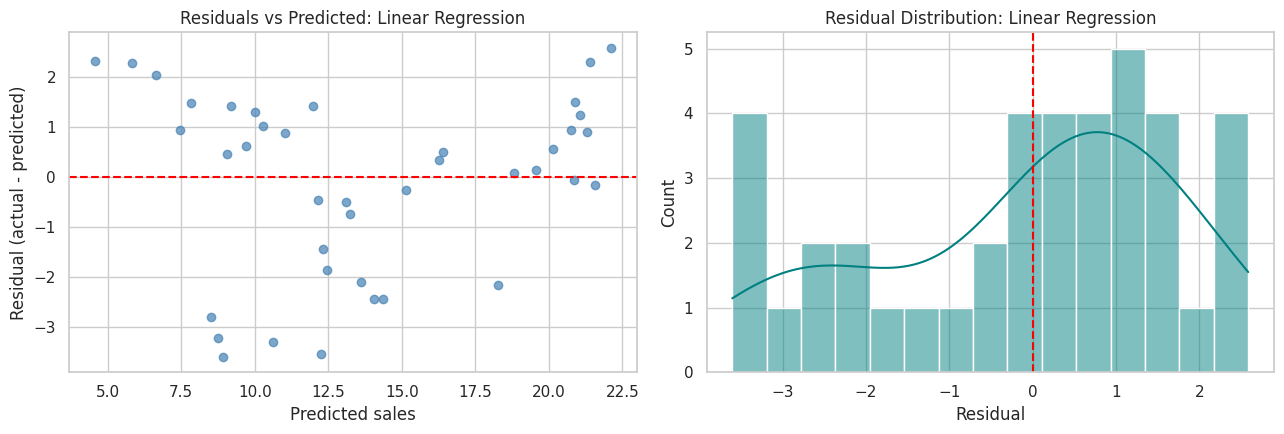

Linear Regression: mean residual = -0.098, std = 1.802


In [16]:
residual_plots(lin_reg, "Linear Regression")

In [17]:
# Numeric check: average residual in low / medium / high predicted-sales groups.
# For a model with no systematic error, every group should average close to zero.
rows = {}
for name in ["Linear Regression", best_name]:
    m = models[name]
    p = pd.Series(m.predict(X_test), index=X_test.index)
    resid = y_test - p
    groups = pd.qcut(p, 3, labels=["Low", "Medium", "High"])
    rows[name] = resid.groupby(groups).mean()

print("Average residual by predicted-sales group")
display(pd.DataFrame(rows).round(2))

Average residual by predicted-sales group


,Linear Regression,Polynomial Regression (deg 2)
Low,0.07,0.18
Medium,-1.02,-0.09
High,0.64,-0.05


### Are the errors random or systematic?
**Best model (Polynomial Regression): essentially random.**
- The residuals are scattered evenly above and below zero across the whole range of predicted sales, with no curve or funnel shape. Almost all of them lie within about +/-1.5 thousand units.
- The mean residual is about 0.02 (very close to zero) and the histogram is roughly centred on zero. The group averages in the table are all close to zero (0.18, -0.09, -0.05).
- There are a few slightly larger positive residuals at low-to-medium predictions (about 7 to 11), but nothing that forms a pattern. With only 40 test points, this level of scatter is normal.

**Baseline (Linear Regression): clearly systematic.**
- The residuals form a **curved (U-shaped) pattern**: the model **under-predicts** at low and high predicted sales (positive residuals) and **over-predicts** in the middle (negative residuals, about -1.0 on average).
- The errors are also about three times as large (standard deviation about 1.8 vs 0.65), reaching +/-3.5.
- This tells us the true relationship is **not a straight line**: TV spend has diminishing returns, and TV and Radio work better together than a plain sum of the two. A straight-line model cannot capture that, which is why adding squared and interaction terms fixes the pattern.

## 9. Interpretation: Which Channel Has the Highest Impact on Sales?

### 9.1 Linear Regression coefficients

,Coefficient (per $1k spent),Std. of spend,Standardised effect
TV,0.0447,84.4189,3.7760
Radio,0.1892,14.8052,2.8011
Newspaper,0.0028,20.3364,0.0562


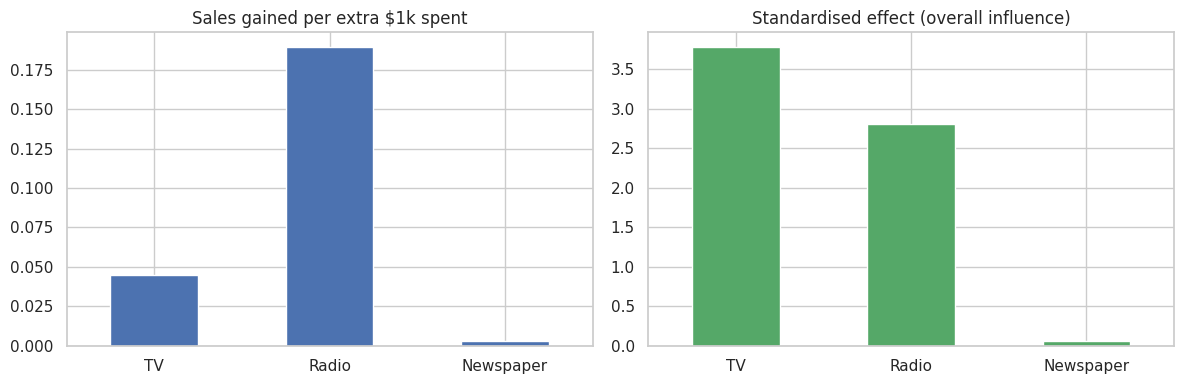

In [18]:
# Raw coefficient = extra sales (thousand units) for each extra $1 thousand spent on that channel
# Standardised coefficient = effect of a 1-standard-deviation change, so channels can be compared fairly
coef_df = pd.DataFrame({
    "Coefficient (per $1k spent)": lin_reg.coef_,
    "Std. of spend": X_train.std().values,
})
coef_df["Standardised effect"] = coef_df["Coefficient (per $1k spent)"] * coef_df["Std. of spend"]
coef_df.index = X.columns
display(coef_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
coef_df["Coefficient (per $1k spent)"].plot(kind="bar", ax=axes[0], color="#4C72B0", rot=0)
axes[0].set_title("Sales gained per extra $1k spent")
coef_df["Standardised effect"].plot(kind="bar", ax=axes[1], color="#55A868", rot=0)
axes[1].set_title("Standardised effect (overall influence)")
plt.tight_layout()
plt.show()

### 9.2 Random Forest feature importance (and permutation importance)

,RF importance,Permutation importance
TV,0.625,1.390
Radio,0.362,0.543
Newspaper,0.013,0.000


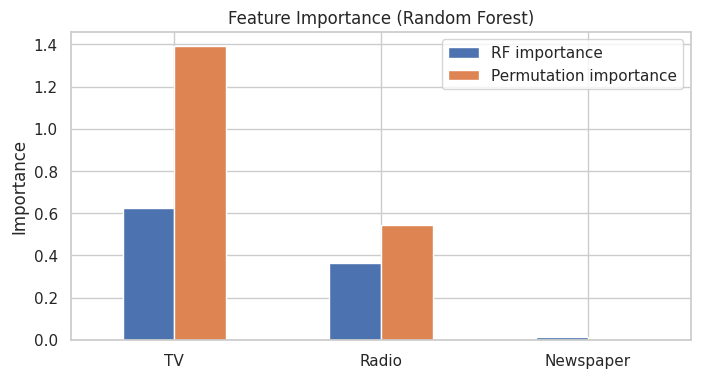

In [19]:
perm = permutation_importance(rf_reg, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE)

imp_df = pd.DataFrame({
    "RF importance": rf_reg.feature_importances_,
    "Permutation importance": perm.importances_mean,
}, index=X.columns)
display(imp_df.round(3))

imp_df.plot(kind="bar", figsize=(8, 4), rot=0, color=["#4C72B0", "#DD8452"])
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")
plt.show()

### Answer: which channel has the highest impact?
All three views agree on the ranking, but they answer two slightly different questions.

**1. Overall influence on sales: TV is highest, Radio second, Newspaper almost none.**
- Standardised effects from Linear Regression: TV about 3.8, Radio about 2.8, Newspaper about 0.06.
- Random Forest importance: TV 0.63, Radio 0.36, Newspaper 0.01. Permutation importance gives the same order (TV about 1.39, Radio about 0.54, Newspaper about 0).
- TV matters most overall because it has the largest budgets and the greatest variation across markets, and its spend is the strongest single driver of sales.

**2. Return per extra dollar: Radio is highest.**
- Each extra $1 thousand adds about **0.19** thousand units on Radio, versus about **0.045** on TV, so a dollar of radio spend is roughly **4 times** as productive as a dollar of TV spend in this data.
- In the what-if test in Section 10, adding 20 to the Radio budget raises predicted sales by about 3.9, while adding 20 to the TV budget raises them by about 0.75.

**3. Newspaper has virtually no effect.**
- Its coefficient (0.003) is close to zero and its permutation importance is about zero. Newspaper only looked related to Sales because it is correlated with Radio (0.35). Once TV and Radio are in the model, it adds nothing.

**Business takeaway:** TV is the biggest overall driver, but the data suggests the next dollar is best spent on Radio, and Newspaper spend could probably be reduced.

**Caveats**
- This is based on association in 200 markets, so it does not prove cause and effect.
- The "per dollar" figures come from the straight-line model. The Polynomial model shows that returns are not constant: TV has diminishing returns, and TV and Radio reinforce each other, so very large radio budgets would not keep paying off at the same rate.

## 10. Predict Sales for a New Advertising Budget

In [20]:
def predict_sales(tv, radio, newspaper, model=best_model):
    """Predict sales (thousand units) from budgets given in thousand dollars."""
    budget = pd.DataFrame([[tv, radio, newspaper]], columns=X.columns)
    sales = model.predict(budget)[0]
    print(f"TV: {tv}k | Radio: {radio}k | Newspaper: {newspaper}k  ->  predicted sales: {sales:.1f} thousand units")
    return sales

# Try these budgets, or change the numbers (TV 1-300, Radio 0-50, Newspaper 0-115)
predict_sales(230, 38, 69)    # big TV and radio budget
predict_sales(45, 39, 45)     # small TV, decent radio
predict_sales(17, 46, 69)     # tiny TV, high radio
predict_sales(180, 11, 58)    # high TV, low radio

TV: 230k | Radio: 38k | Newspaper: 69k  ->  predicted sales: 21.8 thousand units
TV: 45k | Radio: 39k | Newspaper: 45k  ->  predicted sales: 10.5 thousand units
TV: 17k | Radio: 46k | Newspaper: 69k  ->  predicted sales: 8.9 thousand units
TV: 180k | Radio: 11k | Newspaper: 58k  ->  predicted sales: 13.3 thousand units


np.float64(13.304680088266428)

In [21]:
# What-if: how much does each channel add if we increase its budget by 20 from a medium starting point?
base = dict(tv=150, radio=20, newspaper=30)
base_sales = best_model.predict(pd.DataFrame([list(base.values())], columns=X.columns))[0]
print(f"Baseline budget {base} -> {base_sales:.1f}\n")

for ch, col in zip(["tv", "radio", "newspaper"], X.columns):
    new = dict(base)
    new[ch] = base[ch] + 20
    s = best_model.predict(pd.DataFrame([list(new.values())], columns=X.columns))[0]
    print(f"+20 on {col:<10}: sales change = {s - base_sales:+.2f}")

Baseline budget {'tv': 150, 'radio': 20, 'newspaper': 30} -> 14.2

+20 on TV        : sales change = +0.75
+20 on Radio     : sales change = +3.91
+20 on Newspaper : sales change = +0.08


## Conclusion
- The data is clean (no nulls, no duplicates), and the EDA showed that **TV** and **Radio** are strongly related to sales while **Newspaper** is not.
- Three models were trained and compared using MAE, RMSE and R2.
- The best model, residual behaviour and channel interpretation are discussed in Sections 7 to 9.